# Statistical Analysis

Statistical analysis of retail transaction dataset.

In [34]:
# Core data analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, shapiro, chi2_contingency
import warnings
from datetime import datetime

# Interactive plotting libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure display settings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
plt.style.use('seaborn-v0_8')      # Set consistent plotting style
sns.set_palette("husl")            # Use vibrant color palette
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)       # Wide display format


In [35]:
def load_transformed_data(filepath):
    """Load and prepare retail transaction data for analysis"""
    df = pd.read_csv(filepath)
    
    # Convert data types for proper analysis
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df['Quantity'] = df['Quantity'].astype(int)
    df['UnitPrice'] = df['UnitPrice'].astype(float)
    df['CustomerID'] = df['CustomerID'].astype(float)
    
    # Create derived features for analysis
    df['TotalAmount'] = df['Quantity'] * df['UnitPrice']  # Revenue per transaction
    df['Year'] = df['InvoiceDate'].dt.year
    df['Month'] = df['InvoiceDate'].dt.month
    df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
    df['Hour'] = df['InvoiceDate'].dt.hour
    
    print(f"Dataset loaded: {df.shape}")
    print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
    return df

# Load the transformed dataset
df = load_transformed_data("../data/transformed/transformed.csv")
df.head()

Dataset loaded: (406585, 13)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Wednesday,8


## Descriptive Statistics

In [36]:
def generate_descriptive_stats(df, numerical_cols=None):
    """Generate comprehensive descriptive statistics for numerical columns"""
    if numerical_cols is None:
        numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    stats_dict = {}
    for col in numerical_cols:
        if col in df.columns:
            data = df[col].dropna()  # Remove missing values
            stats_dict[col] = {
                'count': len(data), 'mean': data.mean(), 'median': data.median(),
                'std': data.std(), 'min': data.min(), 'max': data.max(),
                'q25': data.quantile(0.25), 'q75': data.quantile(0.75),
                'skewness': stats.skew(data),    # Measure of asymmetry
                'kurtosis': stats.kurtosis(data) # Measure of tail heaviness
            }
    return stats_dict

def display_stats_table(stats_dict):
    """Convert statistics dictionary to formatted DataFrame"""
    return pd.DataFrame(stats_dict).T.round(4)

# Generate descriptive statistics for key business metrics
key_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
stats_summary = generate_descriptive_stats(df, key_cols)
print("Descriptive Statistics Summary:")
display_stats_table(stats_summary)

Descriptive Statistics Summary:


,count,mean,median,std,min,max,q25,q75,skewness,kurtosis
Quantity,406585.0,13.4159,5.00,248.6986,1.000,80995.0,2.00,12.00,301.0844,94300.1010
UnitPrice,406585.0,3.4713,1.95,69.6418,0.001,38970.0,1.25,3.75,446.6738,242497.3034
TotalAmount,406585.0,23.4577,11.80,427.9421,0.001,168469.6,4.68,19.80,332.8061,123619.3475


## Distribution Analysis

Distribution Analysis:


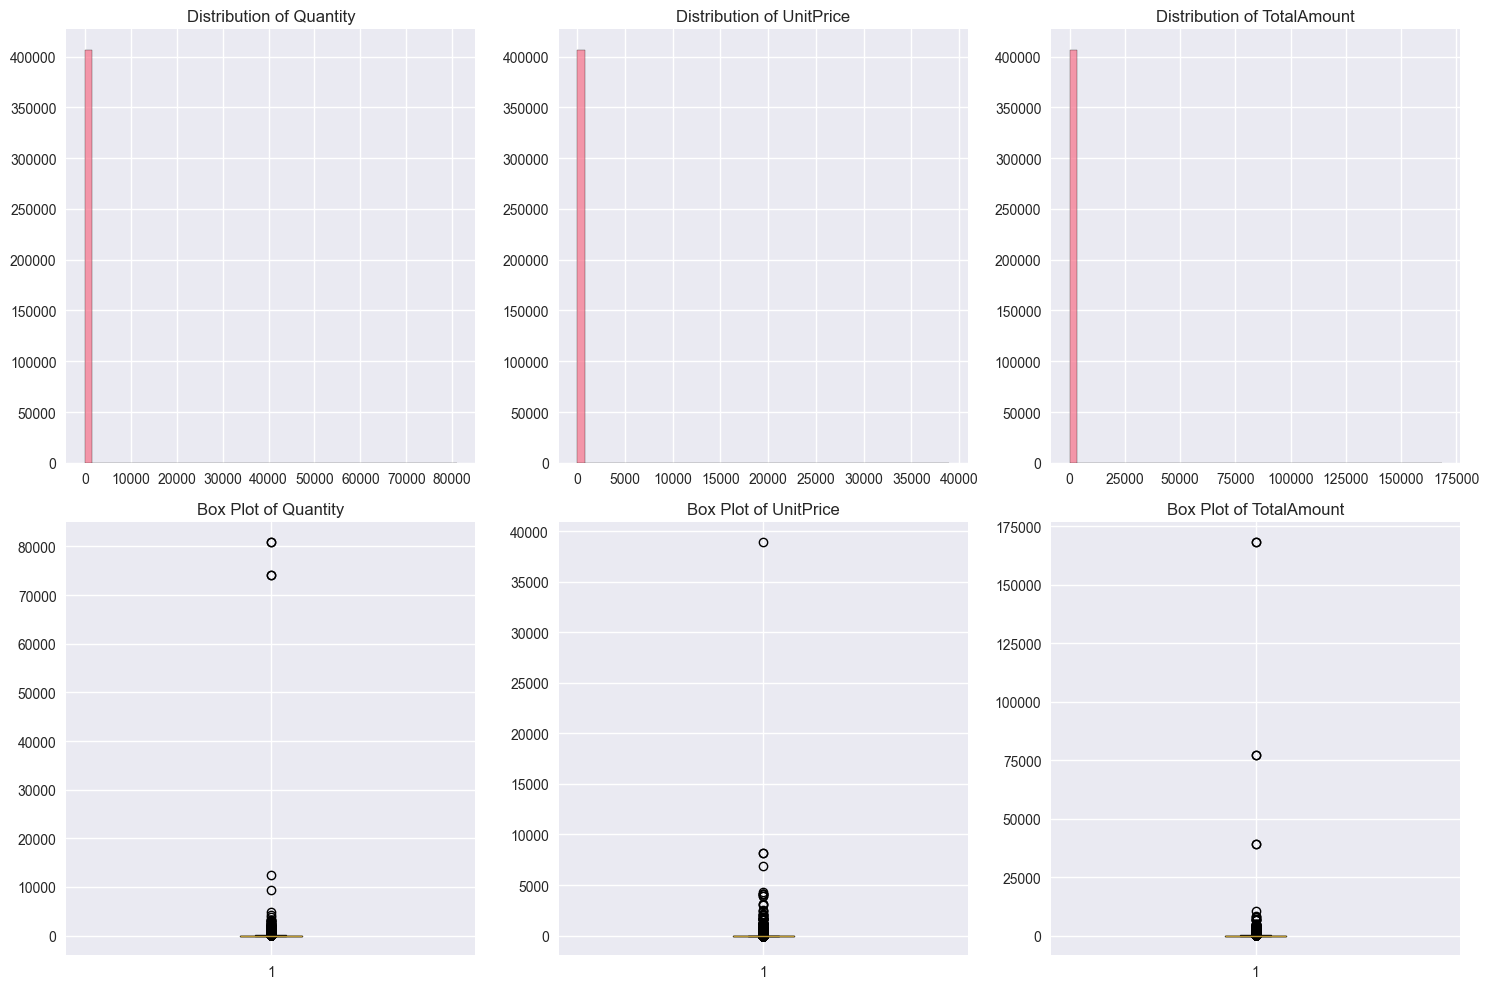


Normality Test Results:


,Column,Shapiro_p,Normal,DAgostino_p,DAgostino_Normal
0,Quantity,8.183567e-90,False,0.0,False
1,UnitPrice,3.674733e-88,False,0.0,False
2,TotalAmount,7.106640e-91,False,0.0,False


In [37]:
def analyze_distributions(df, columns, figsize=(15, 10)):
    """Create histograms and box plots to analyze data distributions"""
    n_cols = len(columns)
    fig, axes = plt.subplots(2, n_cols, figsize=figsize)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, col in enumerate(columns):
        data = df[col].dropna()
        # Histogram shows frequency distribution
        axes[0, i].hist(data, bins=50, alpha=0.7, edgecolor='black')
        axes[0, i].set_title(f'Distribution of {col}')
        # Box plot shows quartiles and outliers
        axes[1, i].boxplot(data)
        axes[1, i].set_title(f'Box Plot of {col}')
    
    plt.tight_layout()
    plt.show()

def test_normality(df, columns, alpha=0.05):
    """Test if data follows normal distribution using statistical tests"""
    results = []
    for col in columns:
        data = df[col].dropna()
        # Use sample for large datasets to avoid computational issues
        sample_data = data.sample(5000, random_state=42) if len(data) > 5000 else data
        shapiro_stat, shapiro_p = shapiro(sample_data)  # Shapiro-Wilk test
        
        # D'Agostino test for larger samples
        if len(data) >= 8:
            dagostino_stat, dagostino_p = normaltest(data)
        else:
            dagostino_stat, dagostino_p = np.nan, np.nan
        
        results.append({
            'Column': col, 'Shapiro_p': shapiro_p, 'Normal': shapiro_p > alpha,
            'DAgostino_p': dagostino_p, 'DAgostino_Normal': dagostino_p > alpha if not np.isnan(dagostino_p) else np.nan
        })
    
    return pd.DataFrame(results)

# Analyze distributions of key variables
print("Distribution Analysis:")
analyze_distributions(df, ['Quantity', 'UnitPrice', 'TotalAmount'])

print("\nNormality Test Results:")
test_normality(df, ['Quantity', 'UnitPrice', 'TotalAmount'])

## Correlation Analysis

Correlation Analysis:


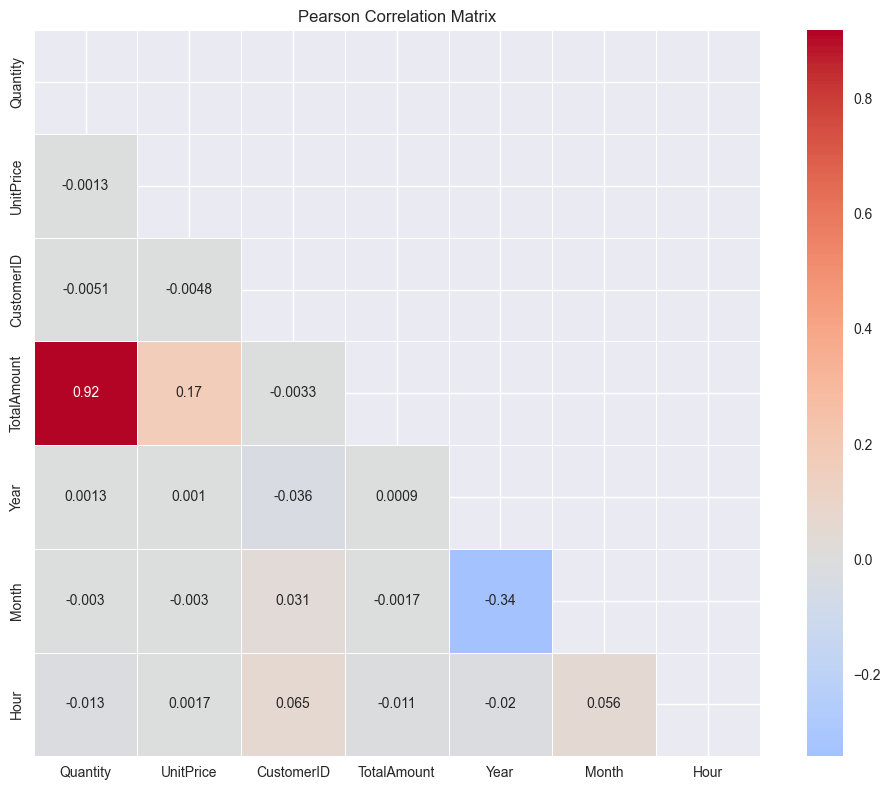


Significant Correlations (|r| >= 0.3):


,Variable_1,Variable_2,Correlation,Strength
0,Quantity,TotalAmount,0.918329,Strong
1,Year,Month,-0.341614,Moderate


In [38]:
def correlation_analysis(df, method='pearson', figsize=(10, 8)):
    """Generate correlation matrix and heatmap visualization"""
    numerical_df = df.select_dtypes(include=[np.number])  # Select only numerical columns
    corr_matrix = numerical_df.corr(method=method)
    
    # Create correlation heatmap with upper triangle mask
    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title(f'{method.capitalize()} Correlation Matrix')
    plt.tight_layout()
    plt.show()
    return corr_matrix

def significant_correlations(corr_matrix, threshold=0.5):
    """Extract correlations above specified threshold"""
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    significant_corr = []
    
    # Find correlations exceeding threshold
    for col in upper_tri.columns:
        for idx in upper_tri.index:
            if not pd.isna(upper_tri.loc[idx, col]) and abs(upper_tri.loc[idx, col]) >= threshold:
                significant_corr.append({
                    'Variable_1': idx, 'Variable_2': col,
                    'Correlation': upper_tri.loc[idx, col],
                    'Strength': 'Strong' if abs(upper_tri.loc[idx, col]) >= 0.7 else 'Moderate'
                })
    
    return pd.DataFrame(significant_corr).sort_values('Correlation', key=abs, ascending=False)

# Perform correlation analysis
print("Correlation Analysis:")
correlation_matrix = correlation_analysis(df)

print("\nSignificant Correlations (|r| >= 0.3):")
significant_correlations(correlation_matrix, threshold=0.3)

## Customer Analysis

In [39]:
def customer_behavior_analysis(df):
    """Analyze customer purchasing behavior and lifetime value"""
    customer_df = df.dropna(subset=['CustomerID'])  # Remove transactions without customer ID
    
    # Aggregate customer-level metrics
    customer_stats = customer_df.groupby('CustomerID').agg({
        'InvoiceNo': 'nunique',         # Number of unique transactions
        'TotalAmount': ['sum', 'mean'], # Total and average spending
        'Quantity': 'sum',              # Total items purchased
        'InvoiceDate': ['min', 'max'],  # First and last purchase dates
        'StockCode': 'nunique'          # Product variety
    })
    customer_stats.columns = ['Transactions', 'Total_Spending', 'Avg_Spending', 
                             'Total_Quantity', 'First_Purchase', 'Last_Purchase', 'Products']
    
    # Calculate customer lifetime in days
    customer_stats['Lifetime_Days'] = (customer_stats['Last_Purchase'] - customer_stats['First_Purchase']).dt.days + 1
    
    return customer_stats, {
        'total_customers': len(customer_stats),
        'avg_transactions': customer_stats['Transactions'].mean(),
        'avg_spending': customer_stats['Total_Spending'].mean()
    }

def rfm_analysis(df):
    """Perform RFM (Recency, Frequency, Monetary) customer segmentation"""
    customer_df = df.dropna(subset=['CustomerID'])
    max_date = customer_df['InvoiceDate'].max()
    
    # Calculate RFM metrics
    rfm = customer_df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (max_date - x.max()).days,  # Days since last purchase
        'InvoiceNo': 'nunique',  # Purchase frequency
        'TotalAmount': 'sum'     # Total monetary value
    })
    rfm.columns = ['Recency', 'Frequency', 'Monetary']
    
    # Create RFM scores using quintiles (1-5 scale)
    rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 5, labels=[5,4,3,2,1])  # Lower recency = higher score
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]) # Higher frequency = higher score
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5])  # Higher monetary = higher score
    
    # Calculate combined RFM score
    rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
    
    # Segment customers based on RFM score
    def segment_customers(score):
        if score >= 12: return 'Champions'    # Best customers
        elif score >= 10: return 'Loyal'     # Loyal customers
        elif score >= 8: return 'Potential'  # Potential loyalists
        elif score >= 6: return 'At Risk'    # At risk customers
        else: return 'Lost'                   # Lost customers
    
    rfm['Segment'] = rfm['RFM_Score'].apply(segment_customers)
    return rfm

# Perform customer behavior analysis
print("Customer Behavior Analysis:")
customer_stats, behavior_summary = customer_behavior_analysis(df)

print("Customer Summary:")
for key, value in behavior_summary.items():
    print(f"  {key}: {value:.2f}")

print("\nTop 10 Customers by Spending:")
top_customers = customer_stats.nlargest(10, 'Total_Spending')[['Transactions', 'Total_Spending', 'Products']]
print(top_customers)

# Perform RFM analysis for customer segmentation
print("\n" + "="*50)
print("RFM Customer Segmentation:")
rfm_results = rfm_analysis(df)

print("\nCustomer Segments Distribution:")
segment_counts = rfm_results['Segment'].value_counts()
print(segment_counts)

print("\nRFM Metrics by Segment:")
segment_metrics = rfm_results.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(segment_metrics)

Customer Behavior Analysis:
Customer Summary:
  total_customers: 4368.00
  avg_transactions: 5.08
  avg_spending: 2183.50

Top 10 Customers by Spending:
            Transactions  Total_Spending  Products
CustomerID                                        
16446.0                3       336942.10         3
14646.0               77       281609.90       703
18102.0               62       262876.11       151
17450.0               55       201619.41       127
14911.0              248       155704.20      1794
12346.0                2       154367.20         1
12415.0               26       126912.65       444
14156.0               66       121375.12       716
16029.0               76       111057.07        46
17511.0               46        93999.38       467

RFM Customer Segmentation:
Customer Summary:
  total_customers: 4368.00
  avg_transactions: 5.08
  avg_spending: 2183.50

Top 10 Customers by Spending:
            Transactions  Total_Spending  Products
CustomerID                     

## Temporal Analysis

Temporal Pattern Analysis:
Best performing day: Thursday
Peak business hour: 12:00
Daily average revenue: $31,270.61
Best performing day: Thursday
Peak business hour: 12:00
Daily average revenue: $31,270.61


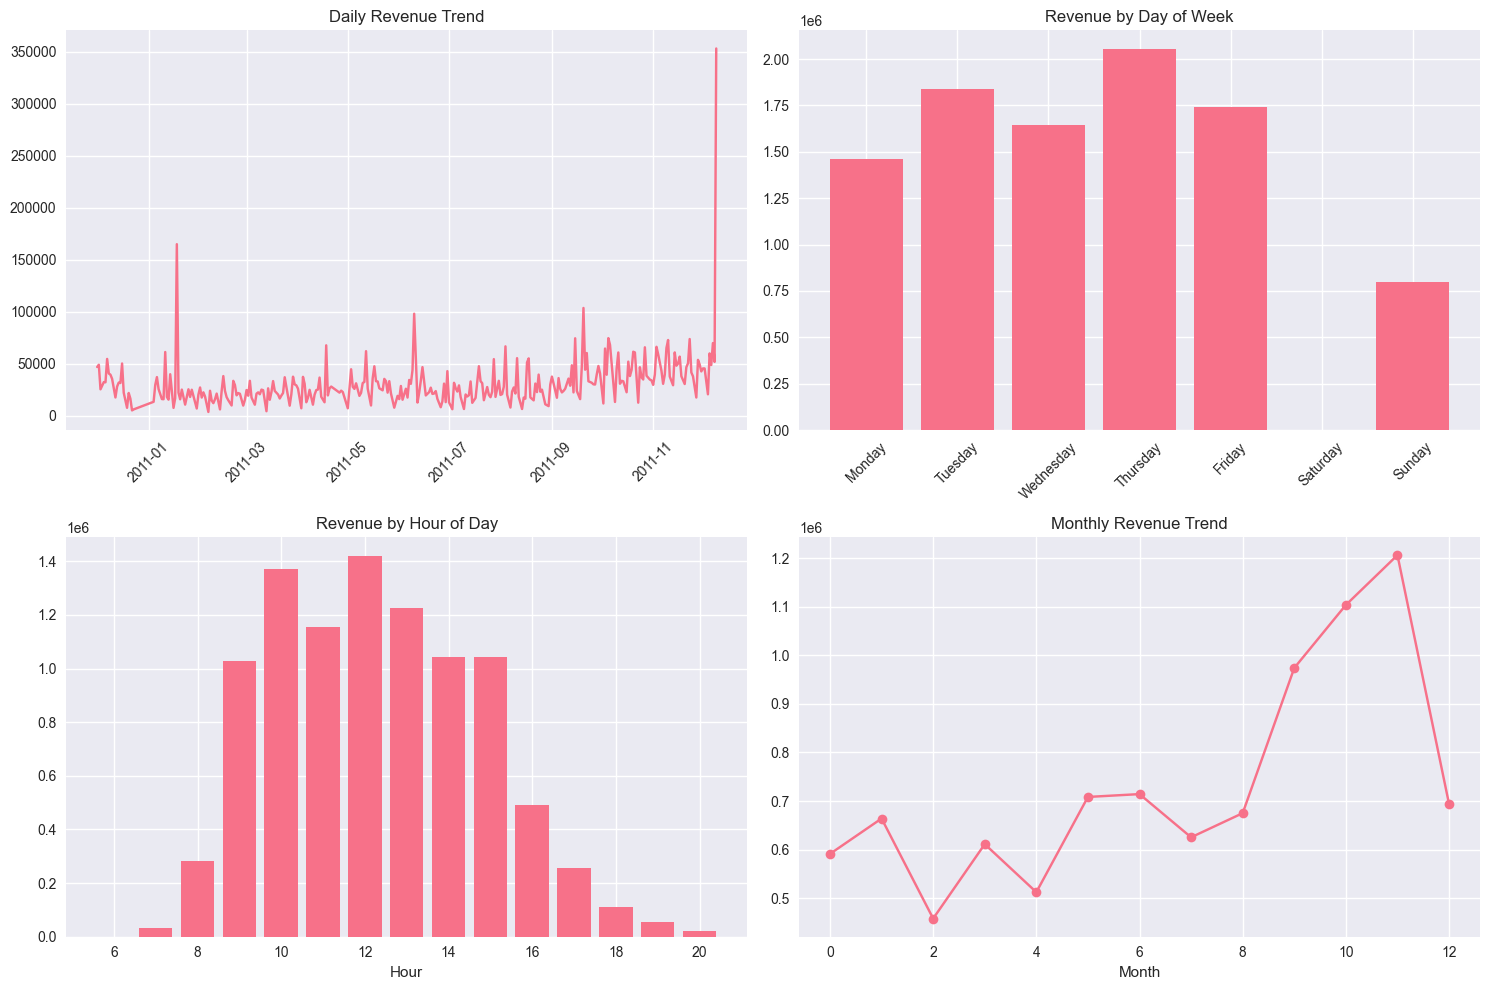

In [40]:
def temporal_analysis(df):
    """Analyze transaction patterns across different time dimensions"""
    # Daily aggregations - sum revenue and count unique transactions/customers
    daily_stats = df.groupby(df['InvoiceDate'].dt.date).agg({
        'TotalAmount': 'sum', 'InvoiceNo': 'nunique', 'CustomerID': 'nunique'
    })
    
    # Monthly aggregations using period to avoid naming conflicts
    year_month = df['InvoiceDate'].dt.to_period('M')  # Group by month-year periods
    monthly_stats = df.groupby(year_month).agg({
        'TotalAmount': 'sum', 'InvoiceNo': 'nunique'
    })
    
    # Day of week patterns - which days generate most revenue
    dow_stats = df.groupby('DayOfWeek')['TotalAmount'].sum()
    
    # Hourly patterns - peak business hours
    hourly_stats = df.groupby('Hour')['TotalAmount'].sum()
    
    return {'daily': daily_stats, 'monthly': monthly_stats, 
            'day_of_week': dow_stats, 'hourly': hourly_stats}

def plot_temporal_trends(temporal_stats, figsize=(15, 10)):
    """Create comprehensive temporal trend visualizations"""
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Daily revenue trend over time
    axes[0, 0].plot(temporal_stats['daily'].index, temporal_stats['daily']['TotalAmount'])
    axes[0, 0].set_title('Daily Revenue Trend')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Revenue by day of week - reorder to standard week format
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_data = temporal_stats['day_of_week'].reindex(dow_order)
    axes[0, 1].bar(dow_data.index, dow_data.values)
    axes[0, 1].set_title('Revenue by Day of Week')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Revenue by hour of day - identify peak business hours
    axes[1, 0].bar(temporal_stats['hourly'].index, temporal_stats['hourly'].values)
    axes[1, 0].set_title('Revenue by Hour of Day')
    axes[1, 0].set_xlabel('Hour')
    
    # Monthly revenue trend
    monthly_data = temporal_stats['monthly']
    axes[1, 1].plot(range(len(monthly_data)), monthly_data['TotalAmount'], marker='o')
    axes[1, 1].set_title('Monthly Revenue Trend')
    axes[1, 1].set_xlabel('Month')
    
    plt.tight_layout()
    plt.show()

# Perform temporal analysis
print("Temporal Pattern Analysis:")
temporal_results = temporal_analysis(df)

# Key insights
print(f"Best performing day: {temporal_results['day_of_week'].idxmax()}")
print(f"Peak business hour: {temporal_results['hourly'].idxmax()}:00")
print(f"Daily average revenue: ${temporal_results['daily']['TotalAmount'].mean():,.2f}")

# Visualize temporal patterns
plot_temporal_trends(temporal_results)

## Product Analysis

In [41]:
def product_analysis(df, top_n=10):
    """Analyze product performance across multiple dimensions"""
    # Group by product (StockCode + Description) and calculate key metrics
    product_stats = df.groupby(['StockCode', 'Description']).agg({
        'TotalAmount': ['sum', 'count'],  # Total revenue and number of transactions
        'Quantity': 'sum',                # Total quantity sold
        'CustomerID': 'nunique'           # Number of unique customers
    })
    product_stats.columns = ['Revenue', 'Transactions', 'Quantity', 'Customers']
    
    return {
        'top_revenue': product_stats.nlargest(top_n, 'Revenue'),       # Highest revenue products
        'top_quantity': product_stats.nlargest(top_n, 'Quantity'),     # Most sold products
        'top_customers': product_stats.nlargest(top_n, 'Customers')    # Products with most customers
    }

def country_analysis(df):
    """Analyze business performance by country/region"""
    return df.groupby('Country').agg({
        'TotalAmount': 'sum',      # Total revenue per country
        'CustomerID': 'nunique',   # Number of unique customers
        'InvoiceNo': 'nunique'     # Number of transactions
    }).sort_values('TotalAmount', ascending=False)  # Sort by revenue

# Perform product performance analysis
print("Product Performance Analysis:")
product_results = product_analysis(df)

print("Top 10 Products by Revenue:")
print(product_results['top_revenue'].head(10))

print(f"\nTotal unique products: {df['StockCode'].nunique():,}")
print(f"Average revenue per product: ${df.groupby('StockCode')['TotalAmount'].sum().mean():,.2f}")

# Perform geographical analysis
print("\n" + "="*50)
print("Country Performance Analysis:")
country_results = country_analysis(df)

print("Top 10 Countries by Revenue:")
top_countries = country_results.head(10)
print(top_countries)

print(f"\nTotal countries served: {len(country_results)}")
print(f"Revenue concentration: Top 3 countries account for {(top_countries['TotalAmount'].head(3).sum() / country_results['TotalAmount'].sum() * 100):.1f}% of total revenue")

Product Performance Analysis:
Top 10 Products by Revenue:
                                                Revenue  Transactions  Quantity  Customers
StockCode Description                                                                     
23843     PAPER CRAFT , LITTLE BIRDIE         336939.20             2    161990          1
M         Manual                              170151.84           465     11174        276
23166     MEDIUM CERAMIC TOP STORAGE JAR      158896.37           208    152410        138
22423     REGENCY CAKESTAND 3 TIER            152417.50          1903     13267        885
85123A    WHITE HANGING HEART T-LIGHT HOLDER  107072.45          2070     39303        858
POST      POSTAGE                              88897.68          1196      3238        379
85099B    JUMBO BAG RED RETROSPOT              87204.80          1662     47296        636
47566     PARTY BUNTING                        70020.93          1416     15563        708
84879     ASSORTED COLOUR BIRD O

## Summary

In [42]:
def export_results(stats_summary, customer_stats, rfm_results, 
                  product_results, country_results, output_dir="../results/"):
    """Export analysis results to CSV files for further use"""
    import os
    os.makedirs(output_dir, exist_ok=True)  # Create results directory if it doesn't exist
    
    # Export each analysis component to separate CSV files
    pd.DataFrame(stats_summary).T.to_csv(f"{output_dir}descriptive_stats.csv")
    customer_stats.to_csv(f"{output_dir}customer_analysis.csv")
    rfm_results.to_csv(f"{output_dir}rfm_analysis.csv")
    product_results['top_revenue'].to_csv(f"{output_dir}top_products.csv")
    country_results.to_csv(f"{output_dir}country_analysis.csv")
    
    print(f"Analysis results exported to: {output_dir}")
    return True

# Final Analysis Summary
print("="*60)
print("           STATISTICAL ANALYSIS COMPLETE")
print("="*60)

# Dataset overview
print("Dataset Overview:")
print(f"   Transactions: {df.shape[0]:,}")
print(f"   Features: {df.shape[1]}")
print(f"   Date Range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

# Business metrics
print("\nBusiness Metrics:")
print(f"   Total Revenue: ${df['TotalAmount'].sum():,.2f}")
print(f"   Unique Customers: {df['CustomerID'].nunique():,}")
print(f"   Unique Products: {df['StockCode'].nunique():,}")
print(f"   Countries Served: {df['Country'].nunique()}")

# Key insights
print("\nKey Insights:")
print(f"   Average Transaction Value: ${df['TotalAmount'].mean():.2f}")
print(f"   Best Performing Day: {temporal_results['day_of_week'].idxmax()}")
print(f"   Peak Business Hour: {temporal_results['hourly'].idxmax()}:00")
print(f"   Customer Segments: {len(rfm_results['Segment'].unique())} identified")

print("\nAnalysis Components Completed:")
print("   - Descriptive Statistics")
print("   - Distribution Analysis") 
print("   - Correlation Analysis")
print("   - Customer Segmentation (RFM)")
print("   - Temporal Pattern Analysis")
print("   - Product Performance Analysis")
print("   - Geographical Analysis")

# Uncomment the line below to export all results to CSV files
# export_results(stats_summary, customer_stats, rfm_results, product_results, country_results)

           STATISTICAL ANALYSIS COMPLETE
Dataset Overview:
   Transactions: 406,585
   Features: 13
   Date Range: 2010-12-01 to 2011-12-09

Business Metrics:
   Total Revenue: $9,537,535.28
   Unique Customers: 4,368
   Unique Products: 3,684
   Countries Served: 36

Key Insights:
   Average Transaction Value: $23.46
   Best Performing Day: Thursday
   Peak Business Hour: 12:00
   Customer Segments: 5 identified

Analysis Components Completed:
   - Descriptive Statistics
   - Distribution Analysis
   - Correlation Analysis
   - Customer Segmentation (RFM)
   - Temporal Pattern Analysis
   - Product Performance Analysis
   - Geographical Analysis
